In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [5]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_development.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
df = pd.read_csv(github_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4157 non-null   float64
 1   volatile acidity      4157 non-null   float64
 2   citric acid           4157 non-null   float64
 3   residual sugar        4157 non-null   float64
 4   chlorides             4157 non-null   float64
 5   free sulfur dioxide   4157 non-null   float64
 6   total sulfur dioxide  4157 non-null   float64
 7   density               4157 non-null   float64
 8   pH                    4157 non-null   float64
 9   sulphates             4157 non-null   float64
 10  alcohol               4157 non-null   float64
 11  quality               4157 non-null   int64  
 12  color                 4157 non-null   object 
 13  wine_id               4157 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 454.8+ KB


In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,wine_id
0,5.8,0.31,0.32,4.5,0.024,28.0,94.0,0.98906,3.25,0.52,13.7,7,white,1198
1,6.3,0.13,0.42,1.1,0.043,63.0,146.0,0.99066,3.13,0.72,11.2,7,white,3409
2,8.2,0.30,0.44,12.4,0.043,52.0,154.0,0.99452,3.04,0.33,12.0,6,white,4789
3,9.4,0.17,0.55,1.6,0.049,14.0,94.0,0.99490,3.02,0.61,10.3,6,white,3054
4,5.3,0.30,0.16,4.2,0.029,37.0,100.0,0.99050,3.30,0.36,11.8,8,white,2812


In [7]:
# Dropping irrelevant columns and target variable

X = df.drop(columns=["wine_id"])
y = X.pop("color")

# checking null values of predictors
X.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

<Axes: title={'center': 'Class distribution'}, xlabel='color'>

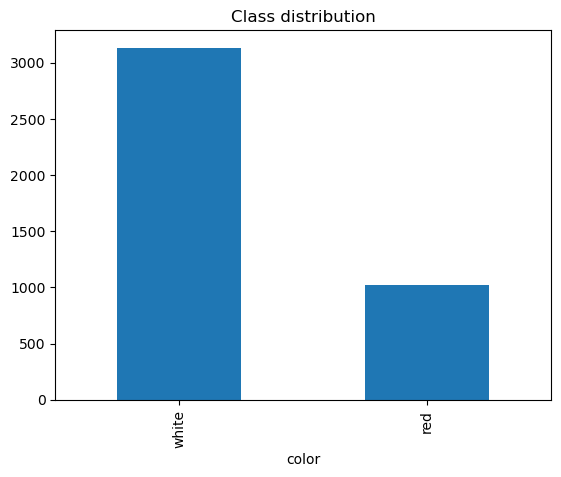

In [8]:
# Visualizing class distribution
y.value_counts(normalize=True)
y.value_counts().plot(kind="bar", title="Class distribution")

In [9]:
# descriptive statistics of predictors
display(X.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4157.0,7.21,1.30,3.90,6.40,7.00,7.70,15.90
volatile acidity,4157.0,0.34,0.17,0.08,0.23,0.29,0.40,1.58
citric acid,4157.0,0.32,0.14,0.00,0.25,0.31,0.39,1.66
residual sugar,4157.0,5.40,4.73,0.60,1.80,3.00,8.10,65.80
chlorides,4157.0,0.06,0.03,0.01,0.04,0.05,0.06,0.61
free sulfur dioxide,4157.0,30.42,17.99,1.00,17.00,29.00,41.00,289.00
total sulfur dioxide,4157.0,115.48,56.85,6.00,77.00,118.00,155.00,440.00
density,4157.0,0.99,0.00,0.99,0.99,0.99,1.00,1.04
pH,4157.0,3.22,0.16,2.74,3.11,3.21,3.32,3.90
sulphates,4157.0,0.53,0.15,0.22,0.43,0.51,0.60,1.95


### Splitting Data

In [10]:
# Splitting the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

In [11]:
# print shapes of the splits
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)



Train shape: (3325, 12) (3325,)
Test shape: (832, 12) (832,)


In [12]:
# Creating a table to show class distribution in train and test sets
dist_table = pd.concat(
    [
        y_train.value_counts(),
        y_test.value_counts()
    ],
    axis=1,
    keys=["Train", "Test"]
)

dist_table = dist_table.fillna(0).astype(int)

dist_table = dist_table.reset_index()
dist_table.columns = ["Color", "Train", "Test"]
display(dist_table.style.hide(axis="index"))


Color,Train,Test
white,2507,627
red,818,205


### Creating Null Model

In [13]:
# Establishing a baseline with DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Null Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Null F1:", f1_score(y_test, y_pred_dummy, average="macro"))

Null Accuracy: 0.7536057692307693
Null F1: 0.4297464016449623


Text(0.5, 1.0, 'Confusion Matrix - Null Model')

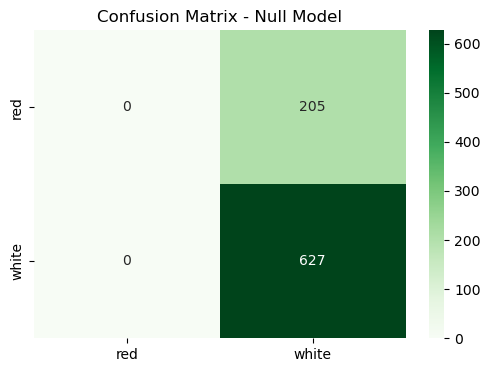

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred_dummy)    

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=dummy.classes_,
    columns=dummy.classes_
)   

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Null Model")


In [15]:
# Detailed classification report for the baseline model
report_dict = classification_report(
    y_test,
    y_pred_dummy,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
print("\n===== CLASSIFICATION REPORT - baseline model =====")
display(report_df.round(2))
# Convert the baseline report to markdown table format
print("\n" + report_df.round(2).to_markdown())


===== CLASSIFICATION REPORT - baseline model =====


/home/stefan/miniconda3/envs/ASDA_2025_Group_3_Porfolio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stefan/miniconda3/envs/ASDA_2025_Group_3_Porfolio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stefan/miniconda3/envs/ASDA_2025_Group_3_Porfolio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

,precision,recall,f1-score,support
red,0.00,0.00,0.00,205.00
white,0.75,1.00,0.86,627.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.38,0.50,0.43,832.00
weighted avg,0.57,0.75,0.65,832.00



|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| red          |        0    |     0    |       0    |    205    |
| white        |        0.75 |     1    |       0.86 |    627    |
| accuracy     |        0.75 |     0.75 |       0.75 |      0.75 |
| macro avg    |        0.38 |     0.5  |       0.43 |    832    |
| weighted avg |        0.57 |     0.75 |       0.65 |    832    |


### Linear SVM

In [16]:
# Training and evaluating a Linear SVM model

linear_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0, random_state=42))
])

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear SVM F1:", f1_score(y_test, y_pred_linear, average="macro"))

Linear SVM Accuracy: 0.9951923076923077
Linear SVM F1: 0.9935270548877737


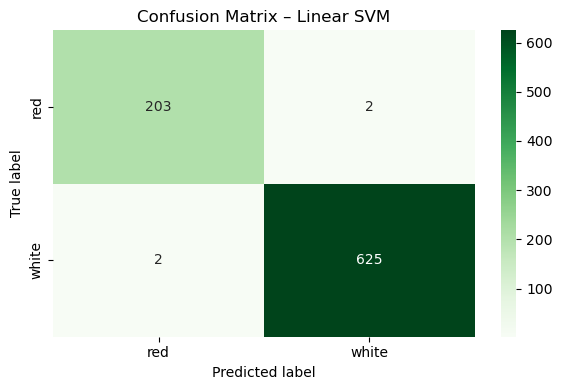

In [17]:
# Confusion matrix for Linear SVM
conf_matrix = confusion_matrix(y_test, y_pred_linear)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=linear_svm.classes_,
    columns=linear_svm.classes_
)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – Linear SVM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [18]:
# Detailed classification report for Linear SVM
report_dict_linear = classification_report(
    y_test,
    y_pred_linear,
    output_dict=True
)

report_df_linear = pd.DataFrame(report_dict_linear).T
print("\n===== CLASSIFICATION REPORT - Linear SVM =====")
display(report_df_linear.round(2))
print("\n" + report_df_linear.round(2).to_markdown())


===== CLASSIFICATION REPORT - Linear SVM =====


,precision,recall,f1-score,support
red,0.99,0.99,0.99,205.0
white,1.00,1.00,1.00,627.0
accuracy,1.00,1.00,1.00,1.0
macro avg,0.99,0.99,0.99,832.0
weighted avg,1.00,1.00,1.00,832.0



|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| red          |        0.99 |     0.99 |       0.99 |       205 |
| white        |        1    |     1    |       1    |       627 |
| accuracy     |        1    |     1    |       1    |         1 |
| macro avg    |        0.99 |     0.99 |       0.99 |       832 |
| weighted avg |        1    |     1    |       1    |       832 |


### Optimizing Linear SVM model parameters through GridSearch

In [19]:
# Parameter tuning with GridSearchCV for Linear SVM
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", random_state=42))
])

parameter_grid = {
    "svc__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_linear = GridSearchCV(
    estimator=pipe_linear,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
grid_linear.fit(X_train, y_train)
best_linear = grid_linear.best_estimator_

print("Best parameter:", grid_linear.best_params_)
print("Best F1:", grid_linear.best_score_)

Best parameter: {'svc__C': 1}
Best F1: 0.9922834597269905


In [20]:
# Summarizing cross-validation results
results = pd.DataFrame(grid_linear.cv_results_)
summary = results[["param_svc__C", "mean_test_score", "std_test_score"]].copy()
summary.rename(columns={
    "param_svc__C": "C",
    "mean_test_score": "CV_F1_mean",
    "std_test_score": "CV_F1_std"
}, inplace=True)

summary.sort_values("CV_F1_mean", ascending=False)


,C,CV_F1_mean,CV_F1_std
3,1.000,0.992283,0.003503
2,0.100,0.991484,0.002980
4,10.000,0.991477,0.003716
5,100.000,0.991474,0.002699
6,1000.000,0.991474,0.002699
1,0.010,0.988661,0.002057
0,0.001,0.982878,0.003380


### Trying out RBF 

In [21]:
# Training and evaluating an RBF SVM model

rbf_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF SVM F1:", f1_score(y_test, y_pred_rbf, average="macro"))


RBF SVM Accuracy: 0.9963942307692307
RBF SVM F1: 0.9951372992139024


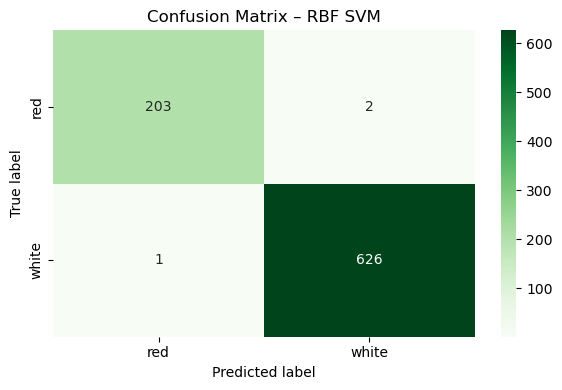

In [22]:
# Confusion matrix for RBF SVM
conf_matrix = confusion_matrix(y_test, y_pred_rbf)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=rbf_svm.classes_,
    columns=rbf_svm.classes_
)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – RBF SVM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [23]:
# Detailed classification report for RBF SVM
report_dict_rbf = classification_report(
    y_test,
    y_pred_rbf,
    output_dict=True
)

report_df_rbf = pd.DataFrame(report_dict_rbf).T
print("\n===== CLASSIFICATION REPORT - RBF SVM =====")
display(report_df_rbf.round(2))
print("\n" + report_df_rbf.round(2).to_markdown())


===== CLASSIFICATION REPORT - RBF SVM =====


,precision,recall,f1-score,support
red,1.0,0.99,0.99,205.0
white,1.0,1.00,1.00,627.0
accuracy,1.0,1.00,1.00,1.0
macro avg,1.0,0.99,1.00,832.0
weighted avg,1.0,1.00,1.00,832.0



|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| red          |           1 |     0.99 |       0.99 |       205 |
| white        |           1 |     1    |       1    |       627 |
| accuracy     |           1 |     1    |       1    |         1 |
| macro avg    |           1 |     0.99 |       1    |       832 |
| weighted avg |           1 |     1    |       1    |       832 |


### Optimizing RBF SVM model parameters through GridSearch

In [24]:
# Parameter tuning with GridSearchCV for RBF SVM
pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42))
])

parameter_grid = {
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rbf = GridSearchCV(
    estimator=pipe_rbf,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_rbf.fit(X_train, y_train)
best_rbf = grid_rbf.best_estimator_

print("Best parameter:", grid_rbf.best_params_)
print("Best F1:", grid_rbf.best_score_)

Best parameter: {'svc__C': 100, 'svc__gamma': 0.01}
Best F1: 0.9939021729974664


In [25]:
# Summarizing cross-validation results for RBF SVM
results = pd.DataFrame(grid_rbf.cv_results_)
summary = results[["param_svc__C", "param_svc__gamma","mean_test_score", "std_test_score"]].copy()
summary.rename(columns={
"param_svc__C": "C",
    "param_svc__gamma": "gamma",
    "mean_test_score": "CV_F1_mean",
    "std_test_score": "CV_F1_std"
}, inplace=True)

# Sort by best CV performance
summary = summary.sort_values("CV_F1_mean", ascending=False)

summary.reset_index(drop=True, inplace=True)

summary

,C,gamma,CV_F1_mean,CV_F1_std
0,100.0,0.01,0.993902,0.002864
1,1000.0,0.001,0.993897,0.003399
2,10.0,0.01,0.993497,0.002359
3,100.0,0.001,0.992691,0.002753
4,1.0,auto,0.992676,0.003301
5,1.0,scale,0.992676,0.003301
6,10.0,auto,0.992672,0.002079
7,10.0,scale,0.992672,0.002079
8,10.0,0.1,0.992672,0.002079
9,1.0,0.1,0.992267,0.002690


### Choosing linear SVM as the final model

In [26]:
final_model = best_linear
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [27]:
svc = final_model.named_steps["svc"]
coef = svc.coef_.ravel()

feature_importance = (
    pd.Series(np.abs(coef), index=X.columns)
      .sort_values(ascending=False)
)

feature_importance

density                 2.321225
residual sugar          1.888663
total sulfur dioxide    1.201288
alcohol                 0.844574
free sulfur dioxide     0.435218
volatile acidity        0.383402
citric acid             0.309800
chlorides               0.278375
sulphates               0.202491
pH                      0.163116
quality                 0.151986
fixed acidity           0.121949
dtype: float64

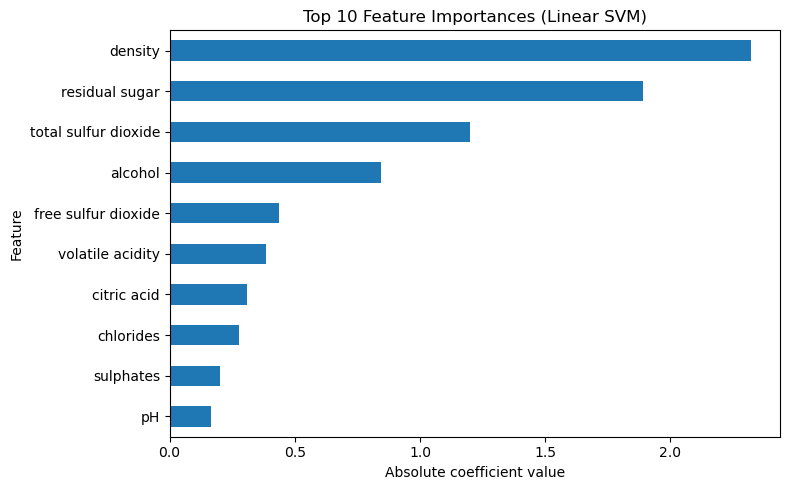

In [28]:
plt.figure(figsize=(8,5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (Linear SVM)")
plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [29]:
signed_importance = pd.Series(coef, index=X.columns).sort_values()
signed_importance.head(), signed_importance.tail()

(density               -2.321225
 alcohol               -0.844574
 free sulfur dioxide   -0.435218
 volatile acidity      -0.383402
 chlorides             -0.278375
 dtype: float64,
 fixed acidity           0.121949
 pH                      0.163116
 citric acid             0.309800
 total sulfur dioxide    1.201288
 residual sugar          1.888663
 dtype: float64)

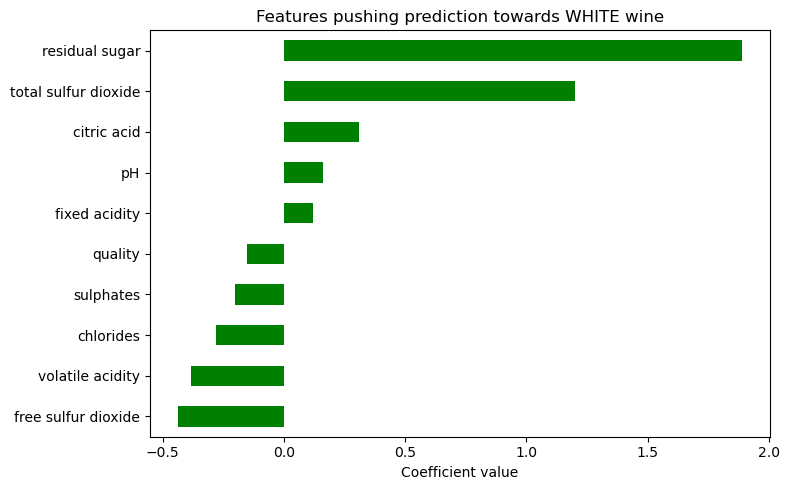

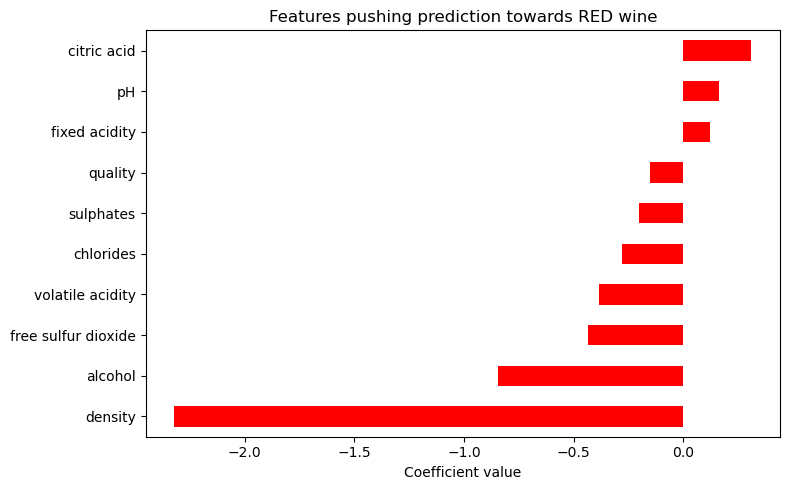

In [30]:
signed_importance = pd.Series(coef, index=X.columns).sort_values()

plt.figure(figsize=(8,5))
signed_importance.tail(10).plot(kind="barh", color="green")
plt.title("Features pushing prediction towards WHITE wine")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
signed_importance.head(10).plot(kind="barh", color="red")
plt.title("Features pushing prediction towards RED wine")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()


### PCA biplot

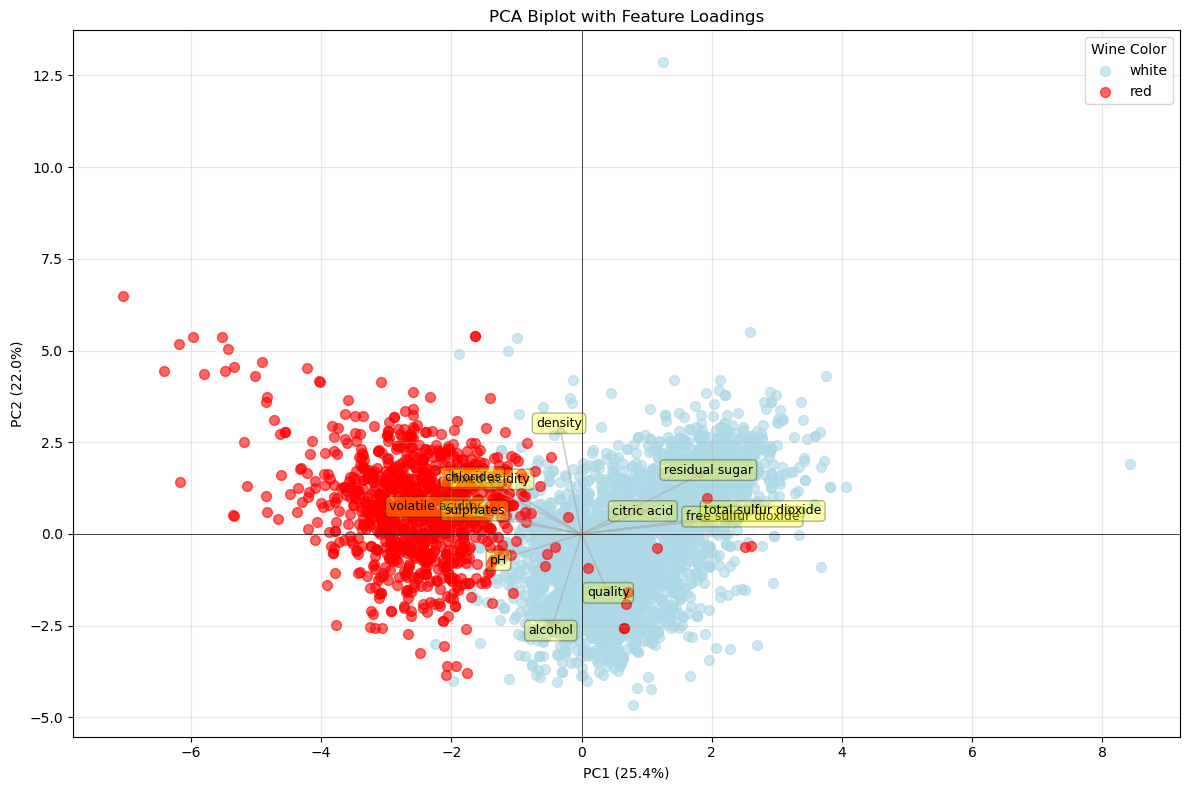

Explained variance PC1: 0.254
Explained variance PC2: 0.220
Total explained variance: 0.473


In [31]:
# PCA Biplot with loadings as arrows
from sklearn.decomposition import PCA

# Fit PCA on the full dataset with all components to compute loadings
pca_full = PCA()
X_scaled = StandardScaler().fit_transform(X)
pca_full.fit(X_scaled)

# Transform data to PCA space (2 components for visualization)
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_scaled)

# Get loadings (components * sqrt(explained_variance))
loadings = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

# Create the biplot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot observations (colored by class)
colors = {'red': 'red', 'white': 'lightblue'}
for color_label in y.unique():
    mask = y == color_label
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               alpha=0.6, label=color_label, s=50, color=colors.get(color_label, 'gray'))

# Plot loading vectors (arrows)
for i, feature in enumerate(X.columns):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
             head_width=0.2, head_length=0.2, fc='darkgray', ec='darkgray', alpha=0.5)
    ax.text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, feature, 
            fontsize=9, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA Biplot with Feature Loadings")
ax.legend(title="Wine Color", loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Explained variance PC1: {pca_2.explained_variance_ratio_[0]:.3f}")
print(f"Explained variance PC2: {pca_2.explained_variance_ratio_[1]:.3f}")
print(f"Total explained variance: {sum(pca_2.explained_variance_ratio_):.3f}")

### Checking Model Performance on Holdout data

### Load Holdout X and Y

In [32]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_holdout_X.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
X_holdout = pd.read_csv(github_url)
X_holdout = X_holdout.drop(columns=['wine_id'])
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1040 non-null   float64
 1   volatile acidity      1040 non-null   float64
 2   citric acid           1040 non-null   float64
 3   residual sugar        1040 non-null   float64
 4   chlorides             1040 non-null   float64
 5   free sulfur dioxide   1040 non-null   float64
 6   total sulfur dioxide  1040 non-null   float64
 7   density               1040 non-null   float64
 8   pH                    1040 non-null   float64
 9   sulphates             1040 non-null   float64
 10  alcohol               1040 non-null   float64
 11  quality               1040 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 97.6 KB


In [33]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_holdout_y.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
y_holdout_df = pd.read_csv(github_url)
y_holdout_df.info()
y_holdout = y_holdout_df.drop(columns=['wine_id'])
y_holdout

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   wine_id  1040 non-null   int64 
 1   color    1040 non-null   object
dtypes: int64(1), object(1)
memory usage: 16.4+ KB


,color
0,white
1,white
2,white
3,red
4,red
...,...
1035,white
1036,white
1037,white
1038,white


In [34]:
# Check holdout data
print(f"Holdout X shape: {X_holdout.shape}")
print(f"Holdout y shape: {y_holdout.shape}")
print(f"\nHoldout class distribution:")
print(y_holdout.value_counts())
print(f"\nHoldout X columns: {list(X_holdout.columns)}")

Holdout X shape: (1040, 12)
Holdout y shape: (1040, 1)

Holdout class distribution:
color
white    784
red      256
Name: count, dtype: int64

Holdout X columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [35]:
# Ensure holdout features match training features exactly
X_holdout = X_holdout[X.columns]

# Evaluate final model on holdout data
y_pred_holdout = final_model.predict(X_holdout)

# Calculate performance metrics
accuracy_holdout = accuracy_score(y_holdout, y_pred_holdout)
f1_holdout = f1_score(y_holdout, y_pred_holdout, average="macro")

print("===== HOLDOUT SET PERFORMANCE =====")
print(f"Accuracy: {accuracy_holdout:.4f}")
print(f"F1-Score (macro): {f1_holdout:.4f}")

===== HOLDOUT SET PERFORMANCE =====
Accuracy: 0.9942
F1-Score (macro): 0.9922


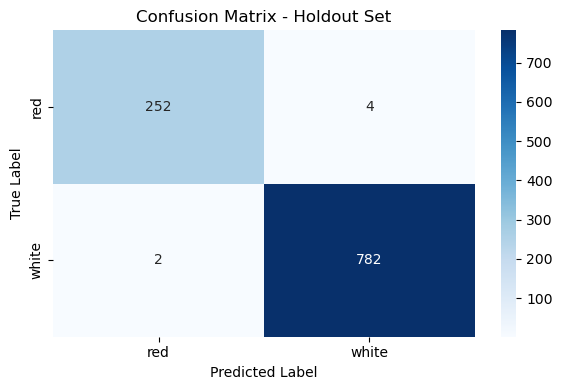

In [36]:
# Confusion matrix for holdout set
conf_matrix_holdout = confusion_matrix(y_holdout, y_pred_holdout)

conf_matrix_holdout_df = pd.DataFrame(
    conf_matrix_holdout,
    index=final_model.classes_,
    columns=final_model.classes_
)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_holdout_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Holdout Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [37]:
# Detailed classification report for holdout set
report_dict_holdout = classification_report(
    y_holdout,
    y_pred_holdout,
    output_dict=True
)

report_df_holdout = pd.DataFrame(report_dict_holdout).T
print("\n===== CLASSIFICATION REPORT - HOLDOUT SET =====")
display(report_df_holdout.round(4))
print("\n" + report_df_holdout.round(2).to_markdown())


===== CLASSIFICATION REPORT - HOLDOUT SET =====


,precision,recall,f1-score,support
red,0.9921,0.9844,0.9882,256.0000
white,0.9949,0.9974,0.9962,784.0000
accuracy,0.9942,0.9942,0.9942,0.9942
macro avg,0.9935,0.9909,0.9922,1040.0000
weighted avg,0.9942,0.9942,0.9942,1040.0000



|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| red          |        0.99 |     0.98 |       0.99 |    256    |
| white        |        0.99 |     1    |       1    |    784    |
| accuracy     |        0.99 |     0.99 |       0.99 |      0.99 |
| macro avg    |        0.99 |     0.99 |       0.99 |   1040    |
| weighted avg |        0.99 |     0.99 |       0.99 |   1040    |
